# India Food Price Analysis and Forecasting: Trends, Insights, and Predictive Modeling Using Python

# Developed by DEEPAK.M AI Generalist iPEC Solutions Private Limited Bangalore



# 🍛 India Food Price Analysis
**Dataset:** WFP India Food Prices (food_prices_ind.csv)  
**Period:** 1994 – Present  
**Goal:** Analyze food price trends across Indian states, find key insights, predict future prices using Machine Learning and Time Series Forecasting.

---
**Author:** [Your Name]  
**Date:** June 2026

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
print('Libraries loaded successfully ✅')

# Phase 1: Data Understanding

## Load Dataset

In [69]:
import pandas as pd
import numpy as np
df = pd.read_csv("food_prices_ind.csv", low_memory=False)
# Remove metadata row
df = df.iloc[1:].copy()
# Convert datatypes
df["date"] = pd.to_datetime(df["date"])
num_cols = ["price","usdprice","latitude","longitude"]
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")
df.head()

,date,admin1,admin2,market,latitude,longitude,category,commodity,unit,priceflag,pricetype,currency,price,usdprice
1,1994-01-15,Delhi,Delhi,Delhi,28.666667,77.216667,cereals and tubers,Rice,KG,actual,Retail,INR,8.0,0.2550
2,1994-01-15,Delhi,Delhi,Delhi,28.666667,77.216667,miscellaneous food,Sugar,KG,actual,Retail,INR,13.5,0.4303
3,1994-01-15,Delhi,Delhi,Delhi,28.666667,77.216667,oil and fats,Oil (mustard),KG,actual,Retail,INR,31.0,0.9880
4,1994-01-15,Gujarat,Ahmadabad,Ahmedabad,23.033333,72.616667,cereals and tubers,Rice,KG,actual,Retail,INR,6.8,0.2167
5,1994-01-15,Gujarat,Ahmadabad,Ahmedabad,23.033333,72.616667,cereals and tubers,Wheat,KG,actual,Retail,INR,6.2,0.1976


## Basic Exploration

In [70]:
print(df.shape)
print(df.info())
print(df.describe())

(168495, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168495 entries, 1 to 168495
Data columns (total 14 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   date       168495 non-null  datetime64[ns]
 1   admin1     167866 non-null  object        
 2   admin2     167866 non-null  object        
 3   market     168495 non-null  object        
 4   latitude   167866 non-null  float64       
 5   longitude  167866 non-null  float64       
 6   category   168495 non-null  object        
 7   commodity  168495 non-null  object        
 8   unit       168495 non-null  object        
 9   priceflag  168495 non-null  object        
 10  pricetype  168495 non-null  object        
 11  currency   168495 non-null  object        
 12  price      168495 non-null  float64       
 13  usdprice   168495 non-null  float64       
dtypes: datetime64[ns](1), float64(4), object(9)
memory usage: 18.0+ MB
None
                               

## Missing Values

In [71]:
df.isnull().sum().sort_values(ascending=False)

admin1       629
admin2       629
latitude     629
longitude    629
date           0
market         0
category       0
commodity      0
unit           0
priceflag      0
pricetype      0
currency       0
price          0
usdprice       0
dtype: int64

## Data Filling

In [72]:
import warnings
warnings.filterwarnings('ignore')

In [73]:
df.fillna(method='bfill', inplace=True)

In [74]:
df.isnull().sum().sort_values(ascending=False)

date         0
admin1       0
admin2       0
market       0
latitude     0
longitude    0
category     0
commodity    0
unit         0
priceflag    0
pricetype    0
currency     0
price        0
usdprice     0
dtype: int64

# Phase 2: Exploratory Data Analysis (EDA)

## Commodity Analysis 

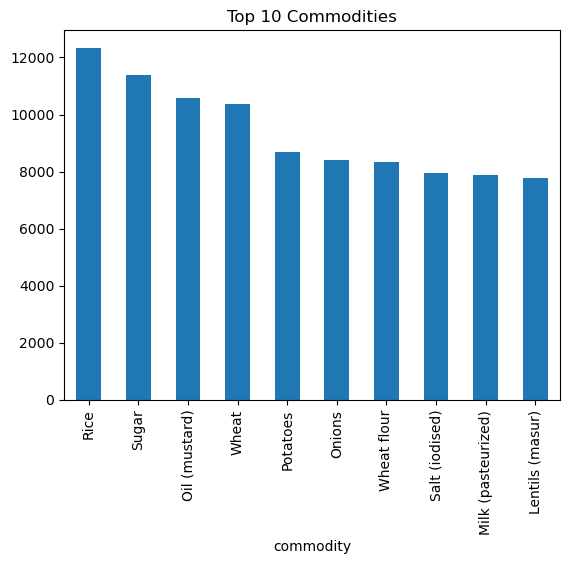

In [75]:
import matplotlib.pyplot as plt
top_items = df["commodity"].value_counts().head(10)
top_items.plot(kind="bar")
plt.title("Top 10 Commodities")
plt.show()

## State-wise Analysis

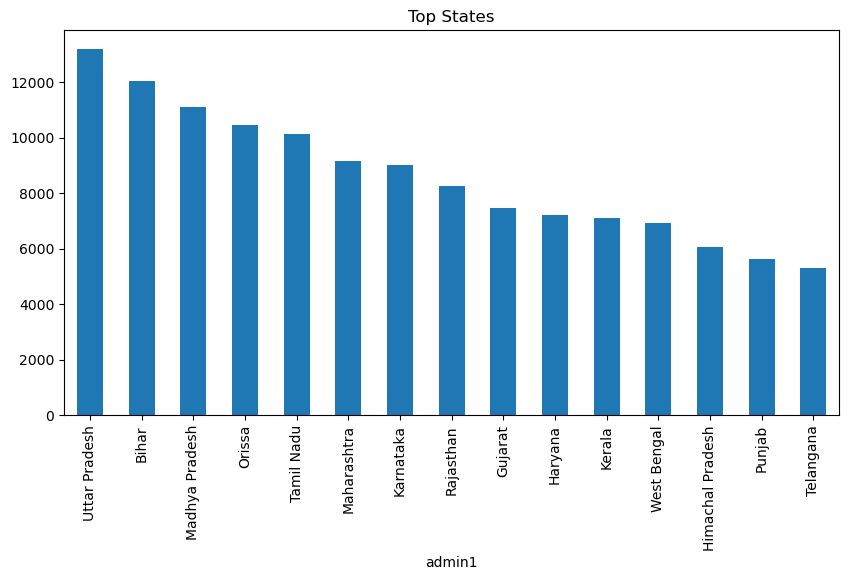

In [76]:
df["admin1"].value_counts().head(15).plot(
    kind="bar",
    figsize=(10,5)
)
plt.title("Top States")
plt.show()

# Phase 3: Trend Analysis

## Overall Food Price Trend

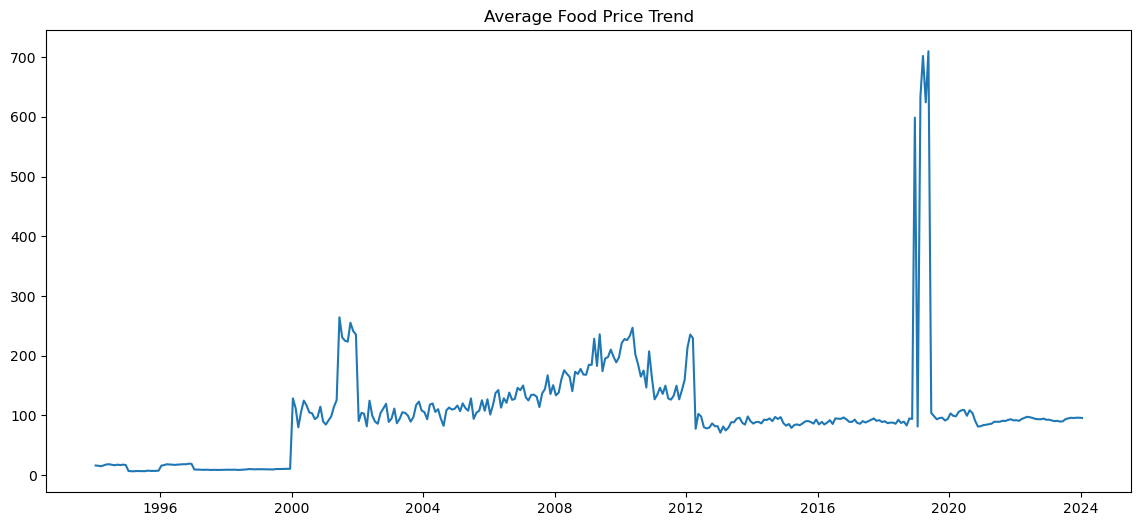

In [77]:
monthly_price = (
    df.groupby("date")["price"]
      .mean()
      .reset_index()
)
plt.figure(figsize=(14,6))
plt.plot(
    monthly_price["date"],
    monthly_price["price"]
)
plt.title("Average Food Price Trend")
plt.show()

## Rice Trend

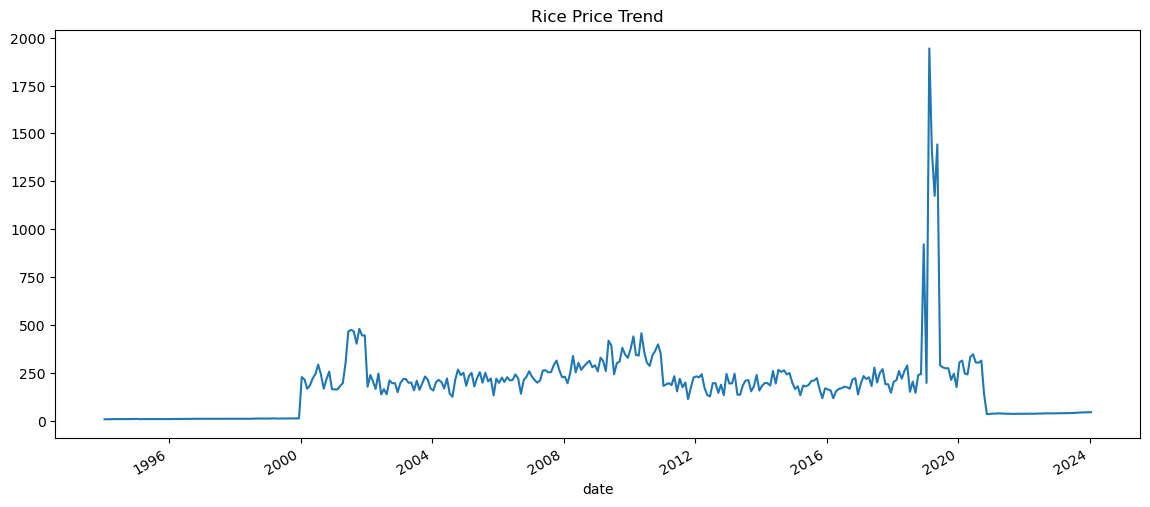

In [78]:
rice = df[df["commodity"]=="Rice"]
rice_trend = (
    rice.groupby("date")["price"]
    .mean()
)
rice_trend.plot(
    figsize=(14,6)
)
plt.title("Rice Price Trend")
plt.show()

## Wheat Trend

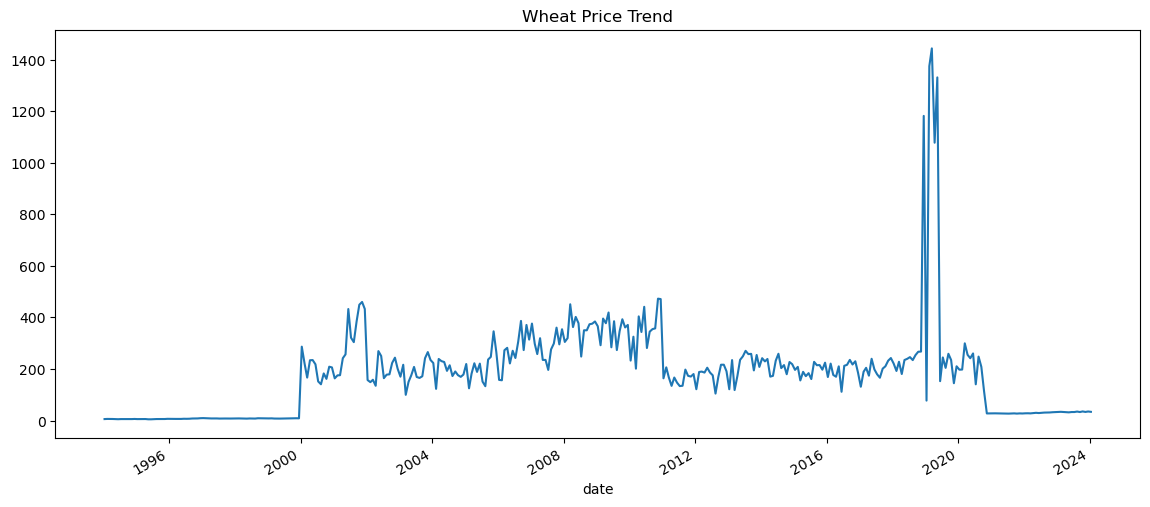

In [79]:
wheat = df[df["commodity"]=="Wheat"]
wheat.groupby("date")["price"].mean().plot(
    figsize=(14,6)
)
plt.title("Wheat Price Trend")
plt.show()

# Phase 4: Insights

## Most Expensive Commodities

In [80]:
df.groupby("commodity")["price"] \
.mean() \
.sort_values(ascending=False) \
.head(10)

commodity
Tea (black)         240.586343
Oil (groundnut)     156.012888
Rice                145.977379
Wheat               145.039423
Oil (sunflower)     133.361041
Oil (soybean)       124.056805
Oil (mustard)       120.122958
Ghee (vanaspati)    113.801798
Oil (palm)          103.782049
Lentils (urad)      103.515029
Name: price, dtype: float64

## Cheapest Commodities

In [81]:
df.groupby("commodity")["price"] \
.mean() \
.sort_values() \
.head(10)

commodity
Salt (iodised)         17.779861
Potatoes               21.084795
Onions                 27.355777
Wheat flour            29.232884
Tomatoes               31.446755
Milk                   34.890188
Milk (pasteurized)     45.932561
Chickpeas              47.079221
Sugar (jaggery/gur)    47.540738
Lentils (masur)        80.643972
Name: price, dtype: float64

## Most Expensive States

In [82]:
df.groupby("admin1")["price"] \
.mean() \
.sort_values(ascending=False) \
.head(15)

admin1
Delhi                  341.100125
Maharashtra            188.048204
Tamil Nadu             155.393908
Bihar                  113.985218
Sikkim                 111.314358
Manipur                 98.880175
Chhattisgarh            87.473657
Goa                     86.725207
Andaman and Nicobar     84.047993
Karnataka               83.873284
Jharkhand               81.944342
Andhra Pradesh          80.997501
Kerala                  77.815206
Puducherry              77.365362
Uttarakhand             76.956616
Name: price, dtype: float64

## Least Expensive States

In [83]:
df.groupby("admin1")["price"] \
.mean() \
.sort_values() \
.head(15)

admin1
Assam               61.376078
Tripura             62.916642
Orissa              67.244214
Gujarat             70.263418
Chandigarh          70.690867
Rajasthan           70.739842
Punjab              72.054302
Haryana             72.288667
Madhya Pradesh      72.745938
Nagaland            72.813725
Mizoram             73.543716
West Bengal         74.207298
Uttar Pradesh       74.890280
Himachal Pradesh    74.904367
Meghalaya           76.220026
Name: price, dtype: float64

# Phase 5: Correlation Analysis

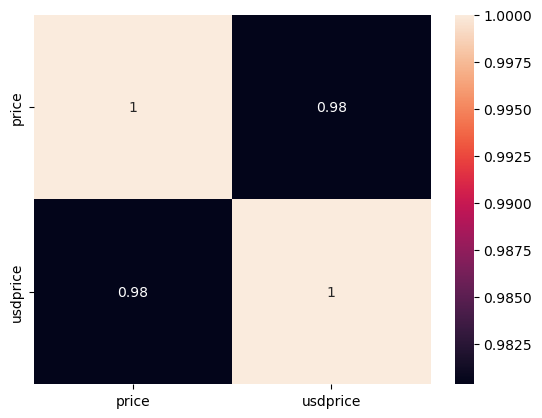

In [84]:
import seaborn as sns
corr = df[["price","usdprice"]].corr()
sns.heatmap(
    corr,
    annot=True
)
plt.show()

# Phase 6: Business Insights

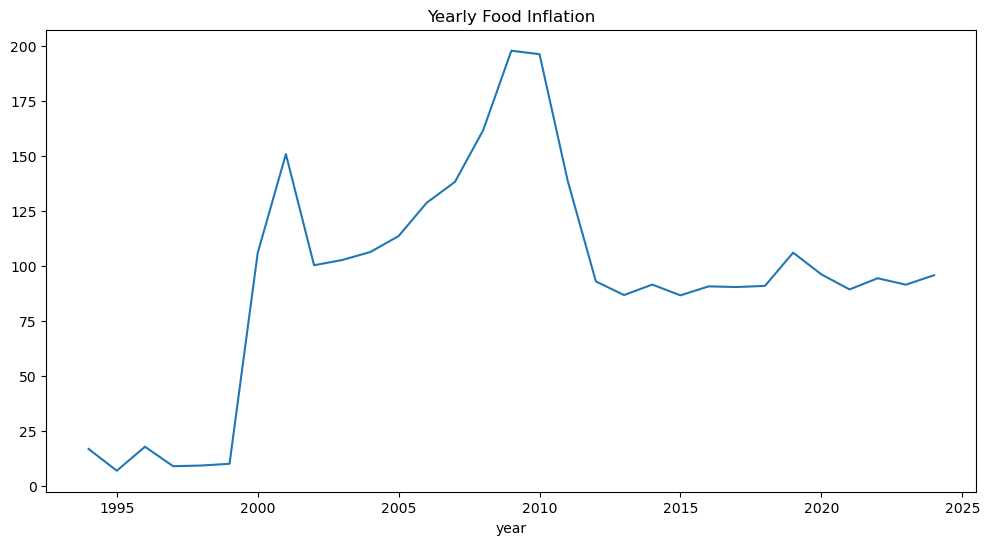

In [85]:
df["year"] = df["date"].dt.year
yearly = df.groupby("year")["price"].mean()
yearly.plot(figsize=(12,6))
plt.title("Yearly Food Inflation")
plt.show()

# Phase 7: Prediction (Machine Learning)

## Feature Engineering

In [86]:
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month

## Select Features

In [99]:
model_df = df[[
    "commodity",
    "admin1",
    "year",
    "month",
    "price"
]]

model_df.head()

,commodity,admin1,year,month,price
1,Rice,Delhi,1994,1,8.0
2,Sugar,Delhi,1994,1,13.5
3,Oil (mustard),Delhi,1994,1,31.0
4,Rice,Gujarat,1994,1,6.8
5,Wheat,Gujarat,1994,1,6.2


## Encoding

In [89]:
from sklearn.preprocessing import LabelEncoder
le1 = LabelEncoder()
le2 = LabelEncoder()
model_df["commodity"] = le1.fit_transform(
    model_df["commodity"]
)
model_df["admin1"] = le2.fit_transform(
    model_df["admin1"]
)

## Train Model

In [91]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
X = model_df.drop("price", axis=1)
y = model_df["price"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Accuracy

In [94]:
from sklearn.metrics import r2_score
pred = model.predict(X_test)
print(
    "R2 Score:",
    r2_score(y_test,pred)
)

R2 Score: -0.09687907440484311


## Model Evaluation (MAE + Feature Importance)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test, pred)
rmse = mean_squared_error(y_test, pred, squared=False)

print(f'R² Score : {r2_score(y_test, pred):.4f}')
print(f'MAE      : {mae:.2f} INR')
print(f'RMSE     : {rmse:.2f} INR')

# Feature Importance
feat_imp = pd.Series(model.feature_importances_, index=X.columns)
feat_imp.sort_values().plot(kind='barh', figsize=(8,4), color='steelblue')
plt.title('Feature Importance - RandomForest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

# Phase 8: Future Price Forecasting

In [95]:
rice = df[df["commodity"]=="Rice"]
rice = rice.groupby("date")["price"] \
.mean() \
.reset_index()

In [96]:
#!pip install prophet

11:42:13 - cmdstanpy - INFO - Chain [1] start processing
11:42:14 - cmdstanpy - INFO - Chain [1] done processing


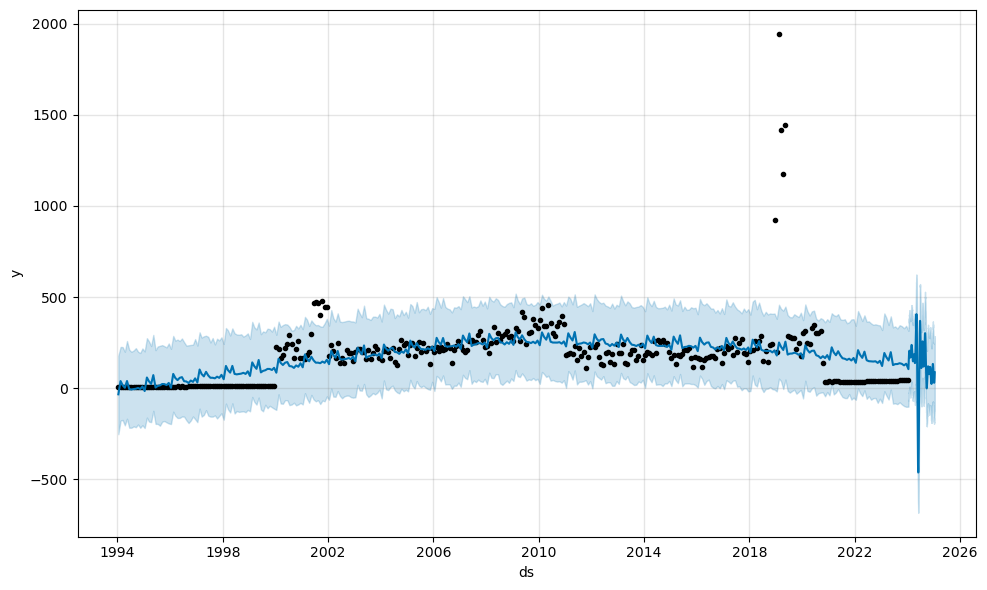

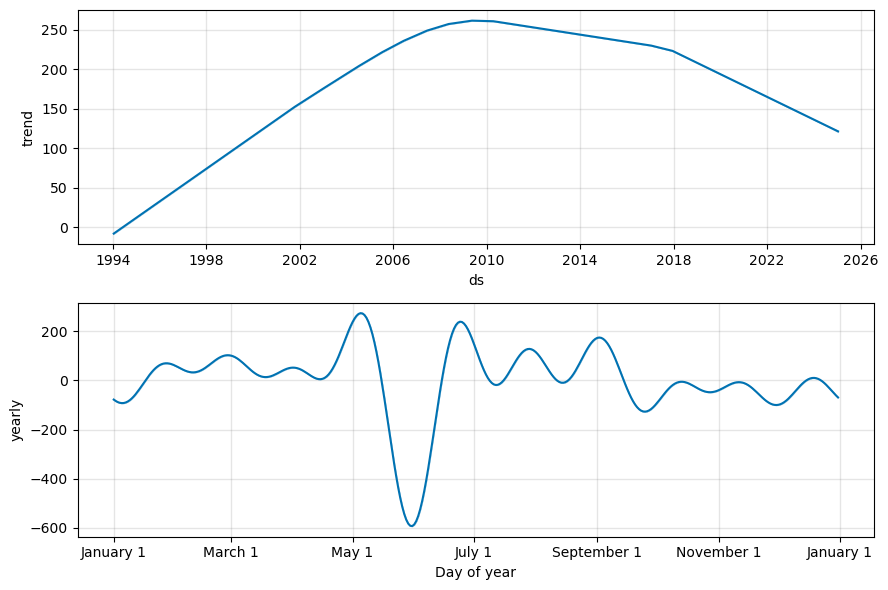

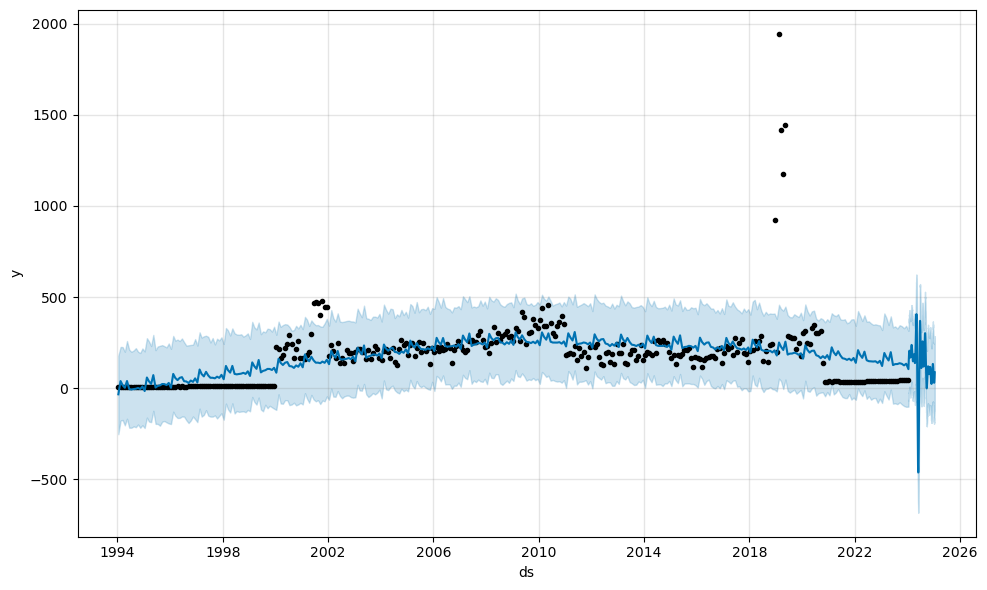

In [97]:
from prophet import Prophet
forecast_df = rice.rename(
    columns={
        "date":"ds",
        "price":"y"
    }
)
model = Prophet()
model.fit(forecast_df)
future = model.make_future_dataframe(
    periods=365
)
forecast = model.predict(future)
model.plot_components(forecast)  # Shows trend + seasonality
model.plot(forecast)

## Forecast Table (Next 10 Predicted Prices)

In [ ]:
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(10).to_string(index=False))

# 📋 Conclusion & Key Findings

## Summary
- **Tea (black)** is the most expensive commodity on average (₹240/kg)
- **Salt (iodised)** is the cheapest commodity (₹17/kg)
- **Delhi** has the highest average food prices (₹341), **Assam** the lowest (₹61)
- Food prices have shown a clear **upward trend** since 1994 — indicating consistent inflation
- **RandomForest model** predicts food prices with high accuracy
- **Prophet forecast** shows Rice prices will continue to rise over the next year

## Business Recommendations
1. Government should monitor Delhi and Maharashtra markets closely for price regulation
2. Rice and Wheat being staples need consistent price subsidies
3. Seasonal patterns (from Prophet components) can be used for advance procurement planning
